# Name: Octavio Morales
# CWID: 20006348
# Assignment: Homework 9- Clustering

### Import and Handling Data

In [15]:
import pandas as pd
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import matplotlib.pyplot as plt

In [16]:
temp= pd.read_csv('wisc_bc_ContinuousVar.csv')
temp.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
temp= temp.dropna()
X= temp.iloc[:, 2:].values
diag= temp.iloc[:, 1]


### Clustering

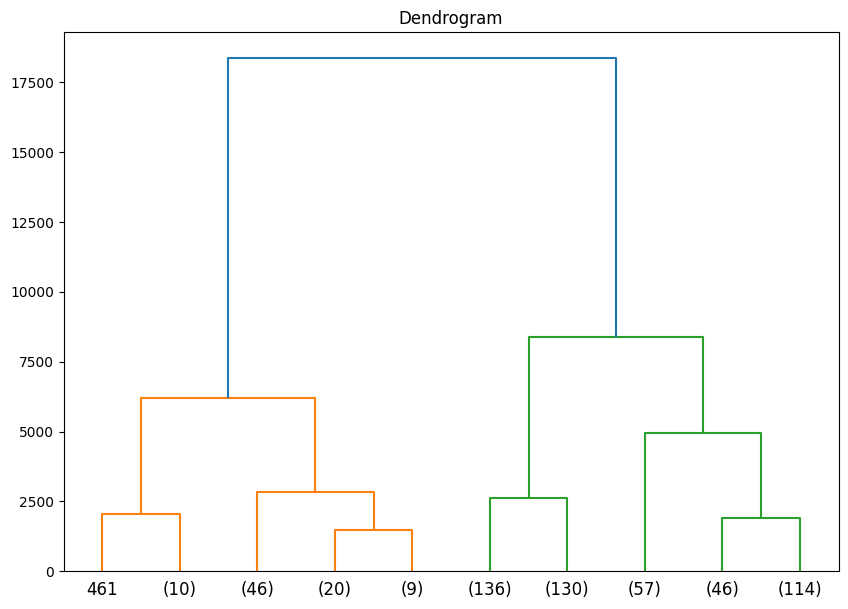

In [18]:
linked= linkage(X, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='lastp', p=10, show_leaf_counts=True)
plt.title('Dendrogram')
plt.show()
clusts= fcluster(linked, 2, criterion='maxclust')


In [19]:
print("Hierarchical Clustering Results:")
print(pd.crosstab(clusts, diag))

Hierarchical Clustering Results:
diagnosis    B    M
row_0              
1            0   86
2          357  126


### K-Means Clustering

In [20]:
kmeans= KMeans(n_clusters=2, random_state=42)
kClus= kmeans.fit_predict(X)
print("K-Means Clustering Results:")
print(pd.crosstab(kClus, diag))

K-Means Clustering Results:
diagnosis    B    M
row_0              
0            1  130
1          356   82
